In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import datetime
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import MSTL, DecomposeResult
import re
import ESP_funcs as esp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from importlib import reload
import pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima

In [2]:
data_full = esp.load_data()

# ARIMA

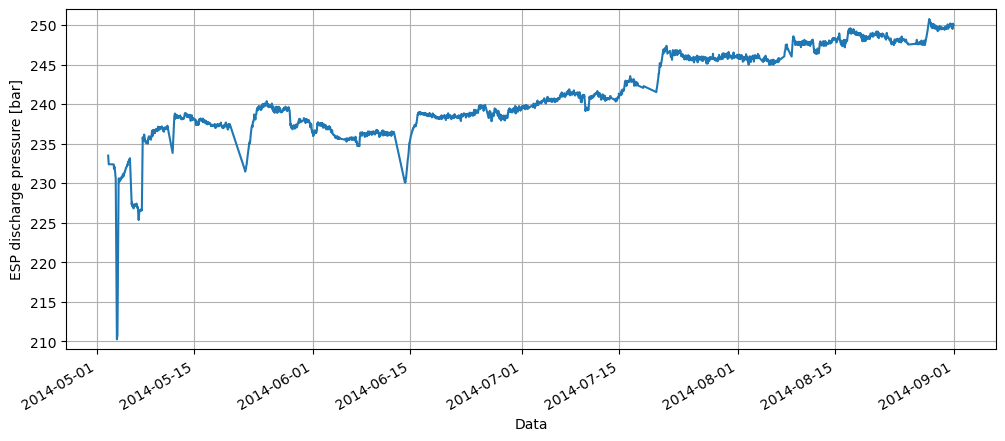

In [13]:
# Getting part of data

year = 2014
month1 = 5
month2 = 9
well = 'A-24 1'
data_name = 'ESP discharge pressure'


reload(esp)
blcks = esp.get_blocks(data_full, well)

well_data = data_full[data_full['Well Run'] ==well]
ind = blcks[1]


ind = ind[np.logical_and(ind.year == year,np.logical_and(ind.month>=month1,ind.month<month2))]
y = well_data.loc[ind,data_name]
y, outliers = esp.remove_outliers(y,diff=1)
ind = y.index


plt.figure(1)
y.plot(style='-')

plt.ylabel('ESP discharge pressure [bar]')
plt.xlabel('Data')
plt.grid(True)
plt.ylim([209,252])
plt.gcf().set_size_inches(12,5)

<Axes: xlabel='time'>

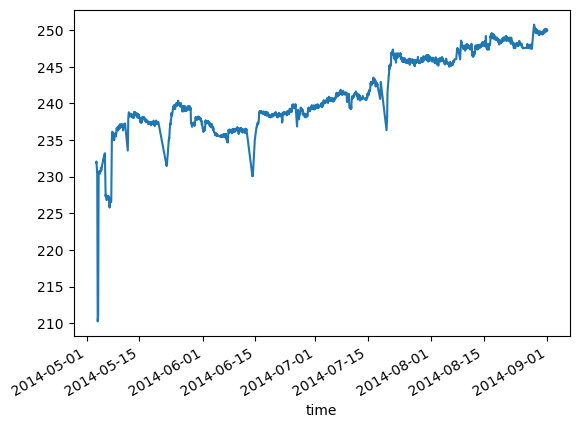

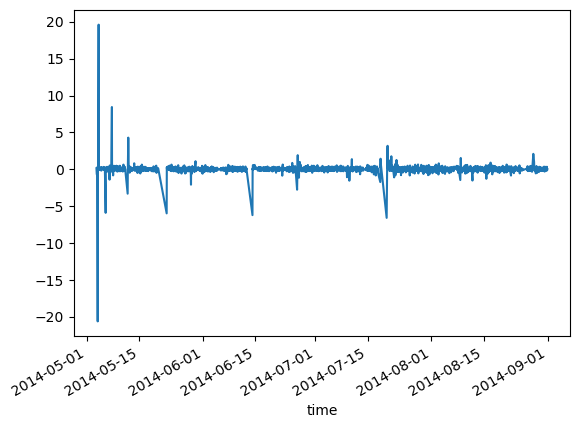

In [4]:
y.plot()

plt.figure()
y.diff().plot()

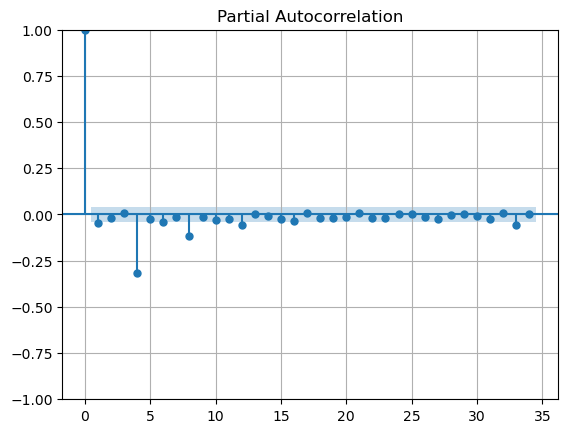

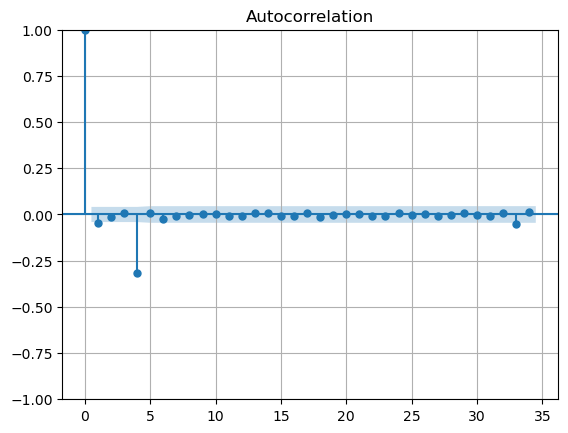

In [5]:
z = y.diff().dropna()
plot_pacf(z);
plt.grid(True)
plot_acf(z);
plt.grid(True)


In [14]:
test_size = 24*10
# Getting data
ord = (12,1,4)

mod = ARIMA(order=ord,with_intercept=False,out_of_sample_size=test_size)
res = mod.fit(y[0:-test_size],disp=0)

res.summary()

c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Heitor\anaconda3\Li

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2249
Model:              SARIMAX(12, 1, 4)   Log Likelihood               -2304.956
Date:                Mon, 13 Jan 2025   AIC                           4643.912
Time:                        12:36:49   BIC                           4741.115
Sample:                             0   HQIC                          4679.392
                               - 2249                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0926      1.228      0.075      0.940      -2.315       2.500
ar.L2          0.0514      0.789      0.065      0.948      -1.495       1.598
ar.L3         -0.0808      0.568     -0.142      0.887      -1.193       1.032
ar.L4          0.3933      0.469      0.838      0.402      -0.526       1.313
ar.L5          0.0292      0.334      0.088      0.930      -0.625       0.684
ar.L6         -0.0287      0.223     -0.128      0.898      -0.466       0.409
ar.L7          0.1528      0.184      0.831      0.406      -0.207       0.513
ar.L8          0.0190      0.131      0.146      0.884      -0.237       0.275
ar.L9         -0.0176      0.081     -0.218      0.828      -0.176       0.141
ar.L10         0.0696      0.071      0.975      0.330      -0.070       0.209
ar.L11         0.0128      0.060      0.212      0.832      -0.105       0.131
ar.L12        -0.0473      0.042     -1.131      0.258      -0.129       0.035
ma.L1         -0.1603      1.229     -0.130      0.896      -2.569       2.249
ma.L2         -0.0687      0.856     -0.080      0.936      -1.746       1.609
ma.L3         -0.3134      0.595     -0.527      0.598      -1.480       0.853
ma.L4         -0.3467      0.921     -0.377      0.706      -2.152       1.458
sigma2         0.4547      0.003    150.235      0.000       0.449       0.461
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):          17845954.91
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.09   Skew:                            -9.84
Prob(H) (two-sided):                  0.00   Kurtosis:                       439.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

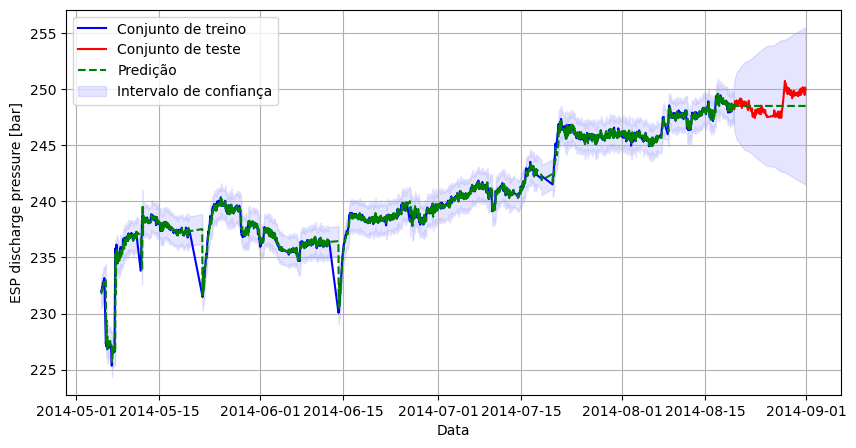

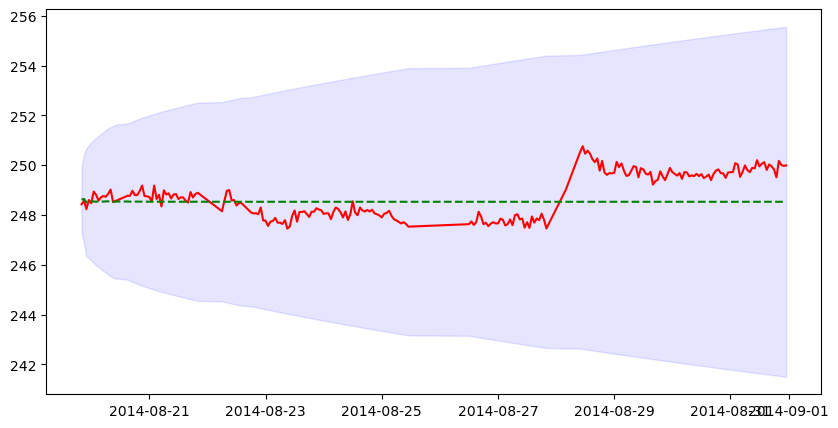

In [18]:
fitted, confint = res.predict(n_periods=test_size, return_conf_int=True)
fitted_vals,confint_sample = res.predict_in_sample(return_conf_int=True)


n = 40
plt.plot(y[n:-test_size],'b-')
plt.plot(y[-test_size:],'r-')

plt.plot(ind[-test_size:],fitted,'g--')


plt.fill_between(ind[-test_size:],confint[-test_size:,0],confint[-test_size:,1],color='b',alpha=0.1)
plt.plot(ind[n:-test_size],fitted_vals[n:],'g--')
plt.fill_between(ind[n:-test_size],confint_sample[n:,0],confint_sample[n:,1],color='b',alpha=0.1)

plt.gcf().set_size_inches(10,5)

plt.xlabel("Data")
plt.ylabel(f'{data_name} [bar]')

plt.legend(['Conjunto de treino', 'Conjunto de teste', 'Predição','Intervalo de confiança'])
plt.grid(True)

plt.figure()
plt.plot(y[-test_size:],'r-')
plt.plot(ind[-test_size:],fitted,'g--')
plt.fill_between(ind[-test_size:],confint[-test_size:,0],confint[-test_size:,1],color='b',alpha=0.1)
plt.gcf().set_size_inches(10,5)

# ARIMAX

-0.1599999999999966 0.18000000000000682
237.52 245.97


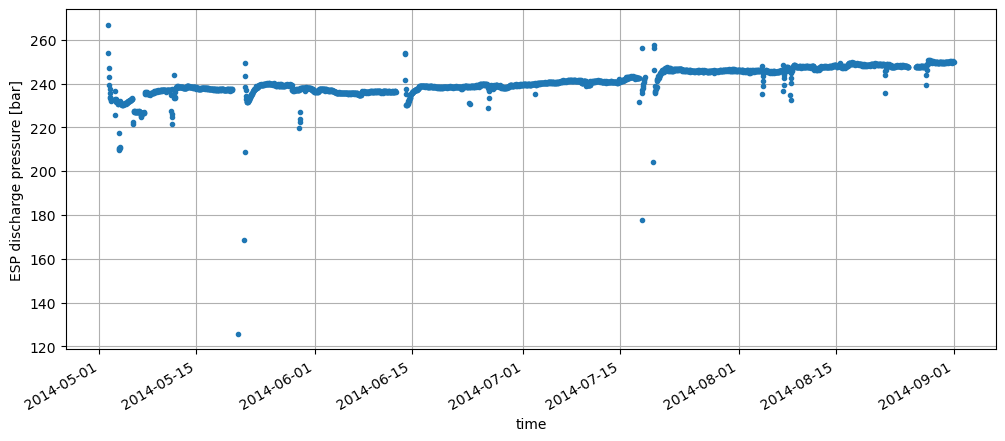

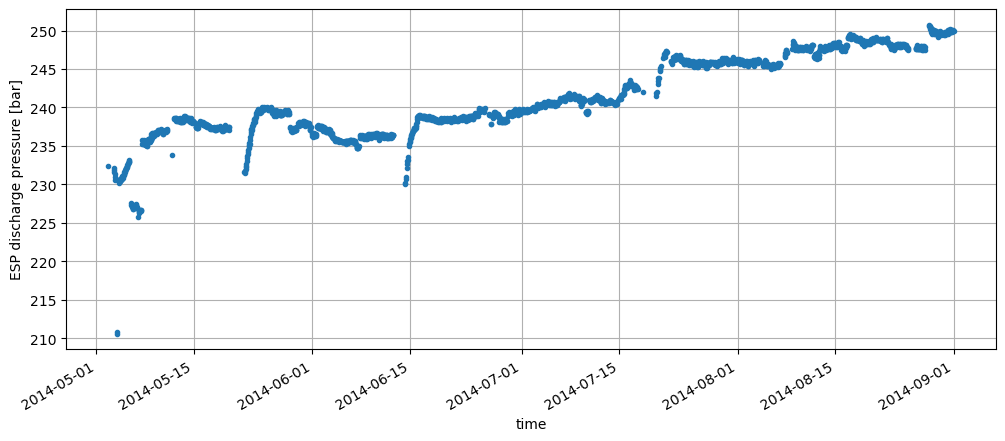

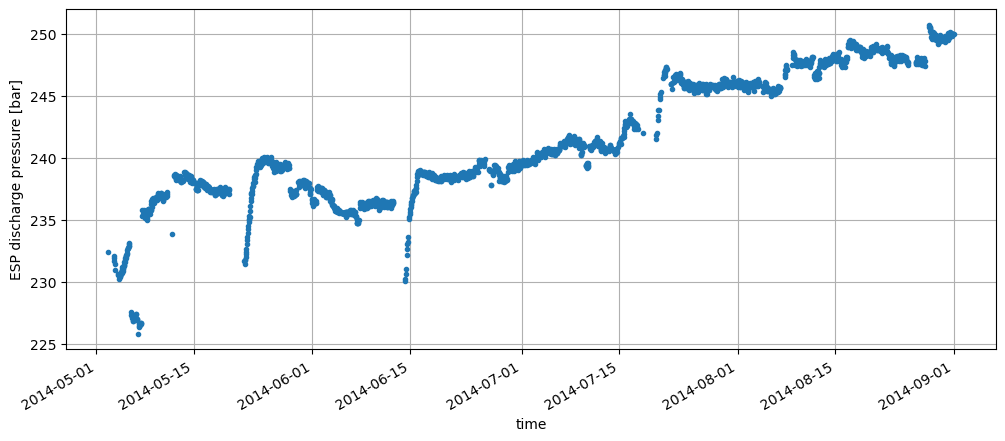

In [174]:
# Getting part of data

year = 2014
month1 = 5
month2 = 9
well = 'A-24 1'
data_name = 'ESP discharge pressure'


reload(esp)
blcks = esp.get_blocks(data_full, well)

well_data = data_full[data_full['Well Run'] ==well]
ind = blcks[1]


ind = ind[np.logical_and(ind.year == year,np.logical_and(ind.month>=month1,ind.month<month2))]
y = well_data.loc[ind,data_name]

yorig = y.copy()


y1, outliers = esp.remove_outliers(y, nIQR = 1,diff=1)

y2, outliers = esp.remove_outliers(y1, nIQR = 1.5,diff=0)

ind = y.index

plt.figure(0)
yorig.plot(style='.')

plt.ylabel('ESP discharge pressure [bar]')
plt.grid(True)
plt.gcf().set_size_inches(12,5)

plt.figure(1)
y1.plot(style='.')

plt.ylabel('ESP discharge pressure [bar]')
plt.grid(True)
plt.gcf().set_size_inches(12,5)

plt.figure(2)
y2.plot(style='.')

plt.ylabel('ESP discharge pressure [bar]')
plt.grid(True)
plt.gcf().set_size_inches(12,5)


In [19]:
# Getting exogenous variables
deg_exog = 12
exog_vars = ['VSD power frequency','ESP motor Current - phase A','ESP motor Current - phase B','ESP motor Current - phase C','Water Cut @ 20degC/1 atm','ESP intake Pressure','ESP Motor Voltage',\
       'Choke Opening']

#'ESP motor Current - phase A'
#'ESP motor Current - phase B'
#'ESP motor Current - phase C'
#'VSD power frequency'
#'ESP intake Pressure'
#'Water Cut @ 20degC/1 atm'
#'ESP Motor Voltage'


exog = well_data.loc[ind,exog_vars].shift(range(deg_exog),fill_value=0)
exog.interpolate(method='linear')

exog.head(3)

,VSD power frequency_0,ESP motor Current - phase A_0,ESP motor Current - phase B_0,ESP motor Current - phase C_0,Water Cut @ 20degC/1 atm_0,ESP intake Pressure_0,ESP Motor Voltage_0,Choke Opening_0,VSD power frequency_1,ESP motor Current - phase A_1,...,ESP Motor Voltage_10,Choke Opening_10,VSD power frequency_11,ESP motor Current - phase A_11,ESP motor Current - phase B_11,ESP motor Current - phase C_11,Water Cut @ 20degC/1 atm_11,ESP intake Pressure_11,ESP Motor Voltage_11,Choke Opening_11
time,,,,,,,,,,,,,,,,,,,,,
2014-05-02 15:00:00,60.10,107.99,109.99,106.99,19.18,103.43,4610.0,36.25,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-05-02 16:00:00,60.27,108.00,110.00,107.00,19.18,103.04,4610.0,36.27,60.10,107.99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-05-02 17:00:00,60.16,108.00,110.00,107.00,19.18,102.86,4610.0,36.25,60.27,108.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
test_size = 24*10
# Getting data
ord = (12,1,4)

mod = ARIMA(order=ord,with_intercept=True,out_of_sample_size=0)
res = mod.fit(y[0:-test_size],X=exog[0:-test_size],trend='c',disp=0)

res.summary()

c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2249
Model:              SARIMAX(12, 1, 4)   Log Likelihood                -579.536
Date:                Mon, 13 Jan 2025   AIC                           1387.072
Time:                        12:49:25   BIC                           2038.901
Sample:                             0   HQIC                          1624.997
                               - 2249                                         
Covariance Type:                  opg                                         
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
intercept                          0.0027      0.154      0.017      0.986      -0.299       0.304
VSD power frequency_0              0.8791      0.064     13.629      0.000       0.753       1.005
ESP motor Current - phase A_0      0.0263      0.024      1.108      0.268      -0.020       0.073
ESP motor Current - phase B_0     -0.0361      0.027     -1.330      0.184      -0.089       0.017
ESP motor Current - phase C_0     -0.0394      0.025     -1.556      0.120      -0.089       0.010
Water Cut @ 20degC/1 atm_0        -2.3931      0.666     -3.593      0.000      -3.698      -1.088
ESP intake Pressure_0             -0.5110      0.014    -35.678      0.000      -0.539      -0.483
ESP Motor Voltage_0                0.0010      0.001      1.442      0.149      -0.000       0.002
Choke Opening_0                   -0.2957      0.032     -9.350      0.000      -0.358      -0.234
VSD power frequency_1             -0.0084      0.084     -0.099      0.921      -0.174       0.157
ESP motor Current - phase A_1     -0.0066      0.028     -0.234      0.815      -0.062       0.049
ESP motor Current - phase B_1     -0.0045      0.030     -0.150      0.881      -0.063       0.054
ESP motor Current - phase C_1     -0.0189      0.031     -0.620      0.535      -0.079       0.041
Water Cut @ 20degC/1 atm_1         0.7367      0.478      1.543      0.123      -0.199       1.673
ESP intake Pressure_1             -0.0943      0.021     -4.401      0.000      -0.136      -0.052
ESP Motor Voltage_1                0.0001      0.001      0.135      0.893      -0.002       0.002
Choke Opening_1                   -0.0606      0.041     -1.467      0.142      -0.141       0.020
VSD power frequency_2             -0.0945      0.098     -0.960      0.337      -0.287       0.098
ESP motor Current - phase A_2      0.0086      0.031      0.277      0.782      -0.052       0.069
ESP motor Current - phase B_2      0.0269      0.033      0.823      0.410      -0.037       0.091
ESP motor Current - phase C_2     -0.0067      0.033     -0.205      0.837      -0.071       0.057
Water Cut @ 20degC/1 atm_2         0.4163      0.535      0.777      0.437      -0.633       1.466
ESP intake Pressure_2             -0.0413      0.033     -1.268      0.205      -0.105       0.023
ESP Motor Voltage_2               -0.0006      0.001     -0.695      0.487      -0.002       0.001
Choke Opening_2                    0.0322      0.089      0.361      0.718      -0.143       0.207
VSD power frequency_3             -0.2058      0.088     -2.331      0.020      -0.379      -0.033
ESP motor Current - phase A_3     -0.0165      0.034     -0.488      0.626      -0.083       0.050
ESP motor Current - phase B_3      0.0295      0.035      0.852      0.394      -0.038       0.098
ESP motor Current - phase C_3      0.0126      0.037      0.341      0.733      -0.060       0.085
Water Cut @ 20degC/1 atm_3         0.9086      0.834      1.090      0.27

c:\Users\Heitor\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


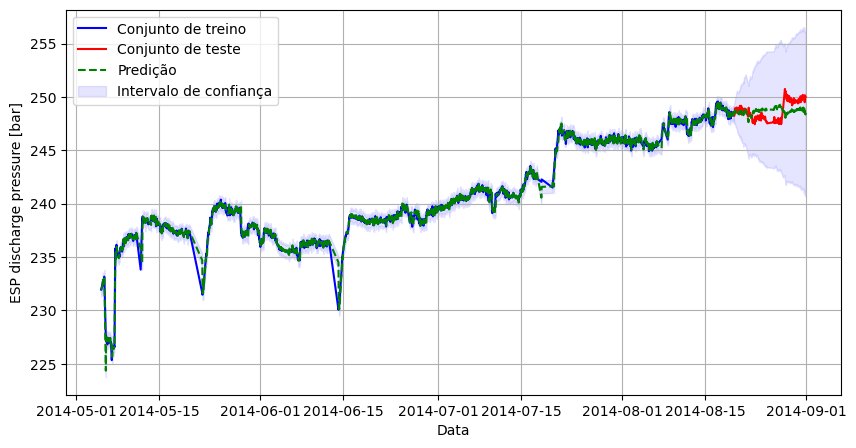

In [21]:
fitted, confint = res.predict(n_periods=test_size,X=exog[-test_size:], return_conf_int=True)
fitted_vals,confint_sample = res.predict_in_sample(return_conf_int=True, X=exog[0:-test_size])


n = 40
plt.plot(y[n:-test_size],'b-')
plt.plot(y[-test_size:],'r-')

plt.plot(ind[-test_size:],fitted,'g--')


plt.fill_between(ind[-test_size:],confint[-test_size:,0],confint[-test_size:,1],color='b',alpha=0.1)
plt.plot(ind[n:-test_size],fitted_vals[n:],'g--')
plt.fill_between(ind[n:-test_size],confint_sample[n:,0],confint_sample[n:,1],color='b',alpha=0.1)

plt.gcf().set_size_inches(10,5)

plt.xlabel("Data")
plt.ylabel(f'{data_name} [bar]')

plt.legend(['Conjunto de treino', 'Conjunto de teste', 'Predição','Intervalo de confiança'])
plt.grid(True)
